# Model A: Random Forest

> **Dataset:** Stroke Prediction Dataset (Kaggle)  
> **Fuente:** https://www.kaggle.com/datasets/fedesoriano/stroke-prediction-dataset  
> **Algoritmo principal:** RandomForestClassifier  
> **Búsqueda de hiperparámetros:** Optuna 

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score

from src.data_loader import load_dataset, get_train_test_split
from src.evaluation import evaluate_model, plot_full_evaluation
from src.model_registry import save_model

%matplotlib inline

## 1. Load Data

In [2]:
df = load_dataset()
X_train, X_test, y_train, y_test = get_train_test_split(df)

Loaded dataset: 5110 rows, 12 columns.
Split: train=4088 rows, test=1022 rows (test_size=0.2, seed=13)


In [3]:
categorical_cols = ["gender", "ever_married", "work_type", "Residence_type", "smoking_status"]

numerical_cols = ["age", "hypertension", "heart_disease", "avg_glucose_level", "bmi"]

## 2. Define Pipeline


### Importar librerías 

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

In [5]:
# Preprocessing para datos numéricos y categóricos
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

### Pipeline completo  

In [6]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=100,
        class_weight="balanced",
        random_state=13,
        n_jobs=-1
    ))
])

In [7]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [8]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

In [9]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.25      0.02      0.04        50

    accuracy                           0.95      1022
   macro avg       0.60      0.51      0.51      1022
weighted avg       0.92      0.95      0.93      1022



### Conclusión — Random Forest baseline 

El modelo Random Forest fue implementado inicialmente con sus parámetros por defecto y evaluado utilizando el umbral estándar de clasificación (threshold = 0.5).

Los resultados obtenidos muestran una alta accuracy (0.95), lo cual en primera instancia podría interpretarse como un buen desempeño. Sin embargo, al analizar métricas más relevantes para este problema desbalanceado, se observa que:

El recall para la clase positiva (stroke) es extremadamente bajo (0.02)

Esto implica que el modelo no está logrando identificar correctamente los casos de stroke

La mayoría de las predicciones se concentran en la clase negativa

Este comportamiento se explica por el fuerte desbalance del dataset, donde la clase 0 (no stroke) domina ampliamente. En este contexto, el modelo tiende a minimizar el error global prediciendo mayoritariamente la clase mayoritaria, lo que impacta negativamente en la detección de eventos críticos.

En consecuencia, se concluye que la accuracy no es una métrica adecuada para evaluar este problema, y que resulta más relevante priorizar métricas como el recall de la clase positiva, dado que el objetivo es identificar la mayor cantidad posible de casos de stroke.

In [10]:
threshold = 0.2
y_pred_adj = (y_proba >= threshold).astype(int)

In [11]:
print(classification_report(y_test, y_pred_adj))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       972
           1       0.18      0.26      0.21        50

    accuracy                           0.91      1022
   macro avg       0.57      0.60      0.58      1022
weighted avg       0.92      0.91      0.91      1022



Tras modificar el umbral de decisión del modelo, se observa un cambio significativo en su comportamiento:

El recall de la clase stroke aumenta de 0.02 a 0.26, lo que implica que el modelo ahora logra identificar una proporción considerablemente mayor de casos positivos.

Sin embargo, este incremento viene acompañado de una disminución en la precision (0.18), lo que indica un aumento en los falsos positivos.

La accuracy desciende de 0.95 a 0.91, lo cual era esperable dado que el modelo ahora asume más riesgo al clasificar instancias como positivas.

Este resultado refleja claramente el trade-off entre recall y precision: al relajar el umbral de decisión, el modelo se vuelve más sensible a detectar casos de stroke, pero pierde exactitud en esas predicciones.

A pesar de esta caída en precisión, el comportamiento actual es más alineado con el objetivo del problema, ya que en contextos médicos resulta preferible identificar la mayor cantidad posible de casos reales, incluso a costa de generar falsas alarmas.

En conclusión, el ajuste del threshold permite transformar un modelo inicialmente sesgado hacia la clase mayoritaria en uno más equilibrado y útil para la detección de eventos críticos, validando la importancia de este paso previo a la optimización de hiperparámetros.

## 3. Hyperparameter Search

El modelo Random Forest depende de varios hiperparámetros que influyen directamente en su capacidad de generalización, complejidad y desempeño. En lugar de seleccionar estos valores manualmente o mediante enfoques exhaustivos como Grid Search, se opta por utilizar Optuna, una herramienta moderna de optimización de hiperparámetros.

Optuna permite explorar de manera eficiente el espacio de búsqueda mediante técnicas de optimización bayesiana, enfocándose en las combinaciones de parámetros más prometedoras a medida que avanza el proceso. Esto resulta especialmente útil para:

Reducir el costo computacional en comparación con búsquedas exhaustivas
Encontrar configuraciones óptimas de forma más rápida
Adaptar la búsqueda en función de resultados previos

En este contexto, Optuna permite mejorar el rendimiento del modelo sin necesidad de definir manualmente todas las combinaciones posibles.

Se seleccionan aquellos hiperparámetros que tienen mayor impacto en el comportamiento del Random Forest:

n_estimators: número de árboles. Más árboles suelen mejorar estabilidad, pero aumentan el costo computacional.
max_depth: profundidad máxima de los árboles. Controla el overfitting.
min_samples_split: mínimo de muestras para dividir un nodo. Regula la complejidad.
min_samples_leaf: mínimo de muestras en una hoja. Ayuda a suavizar el modelo.
max_features: cantidad de variables consideradas en cada split. Introduce aleatoriedad y reduce correlación entre árboles.

Estos parámetros permiten controlar el equilibrio entre bias y variance, impactando directamente en la capacidad del modelo para generalizar correctamente

### Importamos librerías

In [12]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score, recall_score, make_scorer

### Defino metrica objetivo (Recall | F1 )

In [13]:
recall_scorer = make_scorer(recall_score)
f1_scorer = make_scorer(f1_score)

### Función objetivo

In [14]:
def objective_1(trial):

    params = {
        "clf__n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "clf__max_depth": trial.suggest_int("max_depth", 3, 15),
        "clf__min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "clf__min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "clf__max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    }

    pipeline.set_params(**params)

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring=recall_scorer,
        n_jobs=-1
    )

    return scores.mean()

In [15]:
def objective_2(trial):

    params = {
        "clf__n_estimators": trial.suggest_int("n_estimators", 50, 200),
        "clf__max_depth": trial.suggest_int("max_depth", 3, 15),
        "clf__min_samples_split": trial.suggest_int("min_samples_split", 2, 10),
        "clf__min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 5),
        "clf__max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None])
    }

    pipeline.set_params(**params)

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=3,
        scoring=f1_scorer,
        n_jobs=-1
    )

    return scores.mean()

### Ejecutar estudio

In [16]:
study_1 = optuna.create_study(direction="maximize") # Maximizar el recall

study_1.optimize(objective_1, n_trials=25) # Limitar a 25 pruebas para reducir el tiempo de ejecución

# Imprime los mejores parámetros encontrados
print("Mejores parámetros para Recall:")
print(study_1.best_params)

[I 2026-04-24 20:10:26,763] A new study created in memory with name: no-name-b8cbe939-15b9-49d7-bd8e-786abf1f8803
[I 2026-04-24 20:10:30,907] Trial 0 finished with value: 0.28154681139755766 and parameters: {'n_estimators': 79, 'max_depth': 12, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.28154681139755766.
[I 2026-04-24 20:10:34,186] Trial 1 finished with value: 0.48251168400422134 and parameters: {'n_estimators': 149, 'max_depth': 7, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': None}. Best is trial 1 with value: 0.48251168400422134.
[I 2026-04-24 20:10:36,892] Trial 2 finished with value: 0.2863711744308759 and parameters: {'n_estimators': 114, 'max_depth': 8, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 1 with value: 0.48251168400422134.
[I 2026-04-24 20:10:37,323] Trial 3 finished with value: 0.22101613146389265 and parameters: {'n_estimators': 114, 'max_depth': 9, '

Mejores parámetros para Recall:
{'n_estimators': 128, 'max_depth': 3, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': 'sqrt'}


In [17]:
study_2 = optuna.create_study(direction="maximize") # Maximizar el F1-score

study_2 .optimize(objective_2, n_trials=25) # Limitar a 25 pruebas para reducir el tiempo de ejecución

# Imprime los mejores parámetros encontrados
print("Mejores parámetros F1 Score:")
print(study_2.best_params)

[I 2026-04-24 20:10:47,991] A new study created in memory with name: no-name-6a4b121f-bb8e-48a5-b09c-e9ac2ba7d1b5
[I 2026-04-24 20:10:48,452] Trial 0 finished with value: 0.2657971947903249 and parameters: {'n_estimators': 116, 'max_depth': 6, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': None}. Best is trial 0 with value: 0.2657971947903249.
[I 2026-04-24 20:10:49,002] Trial 1 finished with value: 0.04626312384933074 and parameters: {'n_estimators': 189, 'max_depth': 13, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2'}. Best is trial 0 with value: 0.2657971947903249.
[I 2026-04-24 20:10:49,471] Trial 2 finished with value: 0.20375103823379684 and parameters: {'n_estimators': 157, 'max_depth': 13, 'min_samples_split': 6, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: 0.2657971947903249.
[I 2026-04-24 20:10:49,725] Trial 3 finished with value: 0.21034498488948875 and parameters: {'n_estimators': 85, 'max_depth': 3, 'min

Mejores parámetros F1 Score:
{'n_estimators': 192, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 5, 'max_features': None}


## 4. Evaluate Best Model

### Entreno mejor modelo 

In [18]:
best_params = {f"clf__{k}": v for k, v in study_1.best_params.items()} # Ajustar los nombres de los parámetros para el pipeline

best_model = pipeline.set_params(**best_params)
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

### Evaluación sobre modelo final

=== Model A ===
              precision    recall  f1-score   support

           0       0.99      0.69      0.82       972
           1       0.13      0.86      0.22        50

    accuracy                           0.70      1022
   macro avg       0.56      0.78      0.52      1022
weighted avg       0.95      0.70      0.79      1022



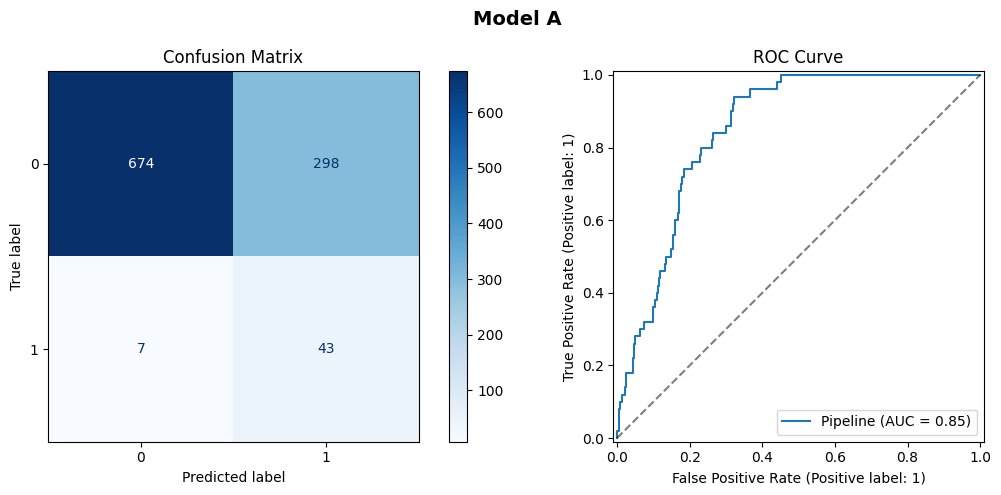

In [ ]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

metrics = plot_full_evaluation(best_model, X_test, y_test, model_name="Model A → Recall Optimized")

La optimización de hiperparámetros mediante Optuna produjo un cambio significativo en el comportamiento del modelo:

El recall de la clase stroke aumenta drásticamente a 0.86, lo que implica que el modelo logra detectar la gran mayoría de los casos positivos.
Sin embargo, este incremento viene acompañado de una precision muy baja (0.13), indicando una alta cantidad de falsos positivos.
La accuracy desciende a 0.70, reflejando que el modelo deja de priorizar la clase mayoritaria.

Este comportamiento evidencia que el modelo ha sido optimizado con un fuerte sesgo hacia la detección de la clase positiva, lo cual es consistente con el objetivo de maximizar el recall durante el proceso de tuning.

Los hiperparámetros encontrados (particularmente una baja profundidad max_depth=3 y mayor restricción en hojas) sugieren un modelo más generalista, que evita el sobreajuste pero amplía la frontera de decisión para incluir más casos como positivos.

En consecuencia, se obtiene un modelo altamente sensible, capaz de detectar la mayoría de los eventos de interés, aunque a costa de una menor precisión.

In [20]:
best_params = {f"clf__{k}": v for k, v in study_2.best_params.items()} # Ajustar los nombres de los parámetros para el pipeline

best_model = pipeline.set_params(**best_params)
best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

=== Model A ===
              precision    recall  f1-score   support

           0       0.98      0.88      0.93       972
           1       0.20      0.56      0.29        50

    accuracy                           0.87      1022
   macro avg       0.59      0.72      0.61      1022
weighted avg       0.94      0.87      0.90      1022



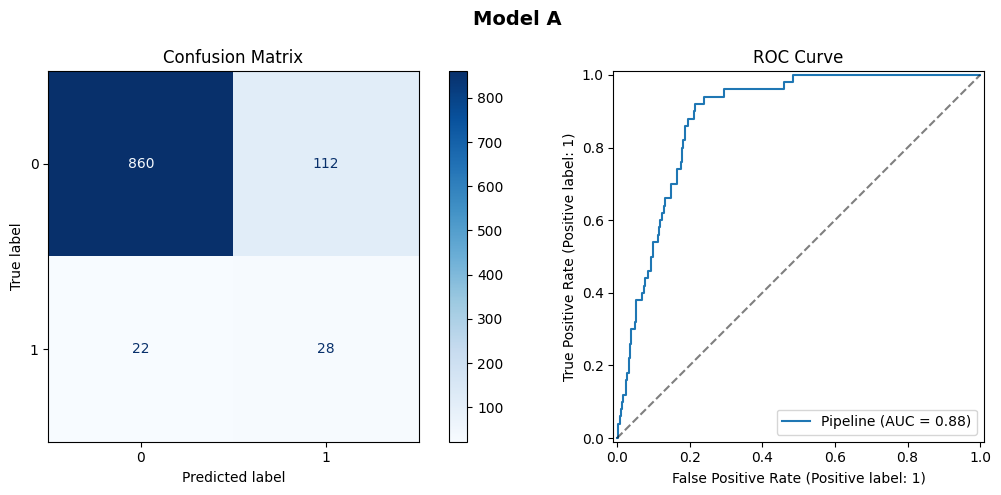

In [ ]:
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

metrics = plot_full_evaluation(best_model, X_test, y_test, model_name="Model A → f1 Score Optimized")

La optimización de hiperparámetros utilizando F1-score como métrica objetivo permitió obtener un modelo más equilibrado en comparación con las versiones anteriores.

El recall de la clase stroke alcanza 0.56, logrando detectar una proporción significativa de casos positivos.
La precision mejora respecto al modelo optimizado por recall (0.20 vs 0.13), reduciendo la cantidad de falsos positivos.
El F1-score (0.29) refleja un mejor balance entre sensibilidad y precisión.
La accuracy (0.87) se mantiene en niveles razonables, sin el sesgo extremo hacia la clase mayoritaria.

En comparación con los enfoques previos:

Se supera ampliamente al modelo baseline, que prácticamente no detectaba casos positivos.
Se logra un comportamiento más estable que el modelo optimizado exclusivamente para recall, que resultaba excesivamente sensible.

En consecuencia, este modelo representa un compromiso adecuado entre detección y precisión, siendo una alternativa más robusta y balanceada para su utilización en etapas posteriores, como el ensamblado con otros modelos.

La optimización debe alinearse con el objetivo del problema, ya que diferentes métricas conducen a modelos con comportamientos muy distintos

## 5. Save Model

In [33]:
save_model(
    model=best_model,
    name="model_A",
    params=study_2.best_params,
    cv_score=study_2.best_value
)

Model saved to C:\Users\lbritez\Desktop\CEIA\AdM\AdM_TP\artifacts\model_A\model.joblib
Params saved to C:\Users\lbritez\Desktop\CEIA\AdM\AdM_TP\artifacts\model_A\params.yaml


WindowsPath('C:/Users/lbritez/Desktop/CEIA/AdM/AdM_TP/artifacts/model_A')

----------------
----------------

## THRESHOLD ANALYSIS

Dado que la optimización orientada exclusivamente a recall produjo un modelo excesivamente sensible, con una alta tasa de falsos positivos, se optó por seleccionar el modelo optimizado en F1-score como base. Este modelo presenta un mejor equilibrio entre precisión y recall, evitando comportamientos extremos.

A partir de este modelo, se realiza un ajuste del threshold de decisión, con el objetivo de incrementar la capacidad de detección de la clase positiva (stroke) sin deteriorar significativamente la precisión. Este enfoque permite desacoplar el aprendizaje del modelo de la política de decisión final, logrando un comportamiento más adaptable al contexto del problema.

In [26]:
y_proba = best_model.predict_proba(X_test)[:, 1]

In [27]:
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.5]

In [ ]:
results = []

for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    
    report = classification_report(y_test, y_pred_thr, output_dict=True)
    
    results.append({
        "threshold": thr,
        "precision": report["1"]["precision"],
        "recall": report["1"]["recall"],
        "f1": report["1"]["f1-score"]
    })

df_results = pd.DataFrame(results)
df_results

,threshold,precision,recall,f1
0,0.20,0.126316,0.96,0.223256
1,0.25,0.153094,0.94,0.263305
2,0.30,0.177165,0.90,0.296053
3,0.35,0.187215,0.82,0.304833
4,0.40,0.179487,0.70,0.285714
5,0.50,0.200000,0.56,0.294737


Tras evaluar distintos valores de threshold sobre el modelo optimizado en F1-score, se observa un comportamiento consistente en el trade-off entre precision y recall. A medida que se reduce el umbral, el modelo incrementa su capacidad de detección de casos positivos, a costa de una mayor cantidad de falsos positivos.

El análisis muestra que el valor threshold = 0.35 maximiza el F1-score (0.30), logrando un equilibrio adecuado entre sensibilidad (recall = 0.82) y precisión (precision = 0.19). Este punto representa un compromiso razonable entre la detección de eventos críticos y la reducción de falsas alarmas, por lo que se selecciona como configuración final del modelo.

In [29]:
best_threshold = 0.35

y_pred_final = (y_proba >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.99      0.82      0.89       972
           1       0.19      0.82      0.30        50

    accuracy                           0.82      1022
   macro avg       0.59      0.82      0.60      1022
weighted avg       0.95      0.82      0.87      1022



El análisis de distintos valores de threshold se utilizó con fines exploratorios para evaluar la sensibilidad del modelo frente a distintos puntos de corte. Sin embargo, el modelo guardado corresponde al resultado del entrenamiento optimizado (Optuna sobre F1), sin incorporar el threshold dentro del proceso de entrenamiento. En un escenario más riguroso, el threshold debería calibrarse utilizando un conjunto de validación independiente.